In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression,LinearRegression


from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer,MissingIndicator

In [2]:
df = pd.read_csv('student-por.csv')

In [4]:
df.sample(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
571,MS,M,19,U,GT3,T,2,1,at_home,other,...,4,4,3,1,3,5,4,8,9,9
508,MS,M,17,R,GT3,T,2,2,other,other,...,4,4,5,1,2,5,0,10,9,9
496,MS,F,16,R,LE3,T,1,1,services,services,...,4,4,4,2,2,4,2,14,14,14
218,GP,F,16,R,GT3,T,2,2,services,services,...,5,3,5,1,1,5,6,13,13,13
225,GP,M,17,U,LE3,T,4,4,services,other,...,5,3,5,4,5,3,15,13,12,12
39,GP,F,15,R,GT3,T,2,2,at_home,other,...,4,3,1,1,1,2,8,14,13,12
270,GP,M,16,U,GT3,T,4,4,services,services,...,5,3,2,1,2,5,4,14,15,15
165,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,2,13,13,13
223,GP,F,17,R,GT3,T,4,3,teacher,other,...,4,4,2,1,1,4,0,11,12,12
558,MS,M,17,R,GT3,T,2,2,other,other,...,5,5,5,3,5,5,0,8,13,10


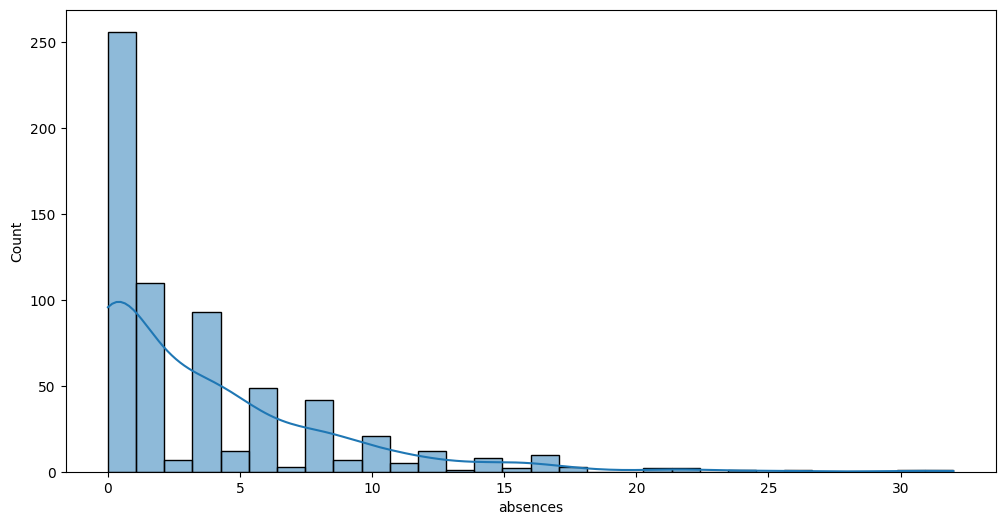

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df["absences"], kde=True, bins=30)
plt.show()

In [6]:
# find highest and lowest
print("highest allowed",df["absences"].mean() + 3*df["absences"].std())
print("lowest allowed",df["absences"].mean() - 3*df["absences"].std())

highest allowed 17.581752542294694
lowest allowed -10.262800308088224


In [7]:
new_df=df[(df["absences"] > 17.5) | (df["absences"] < -3.5)]

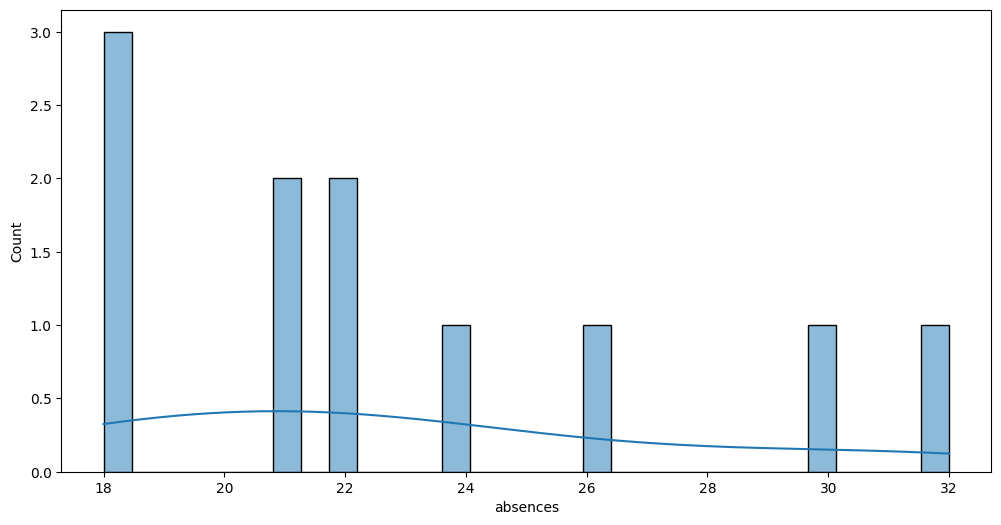

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(data=new_df["absences"], kde=True, bins=30)
plt.show()

In [9]:
new_df.shape

(11, 33)

In [10]:
upper_limit = df["absences"].mean() + 3 * df["absences"].std()
lower_limit = df["absences"].mean() - 3 * df["absences"].std()


# capping the outliers
df["absences"] = np.where(
df["absences"] > upper_limit, upper_limit,
np.where(df["absences"] < lower_limit, lower_limit, df["absences"])
)

print("cap outliers",df["absences"])

cap outliers 0      4.0
1      2.0
2      6.0
3      0.0
4      0.0
      ... 
644    4.0
645    4.0
646    6.0
647    6.0
648    4.0
Name: absences, Length: 649, dtype: float64


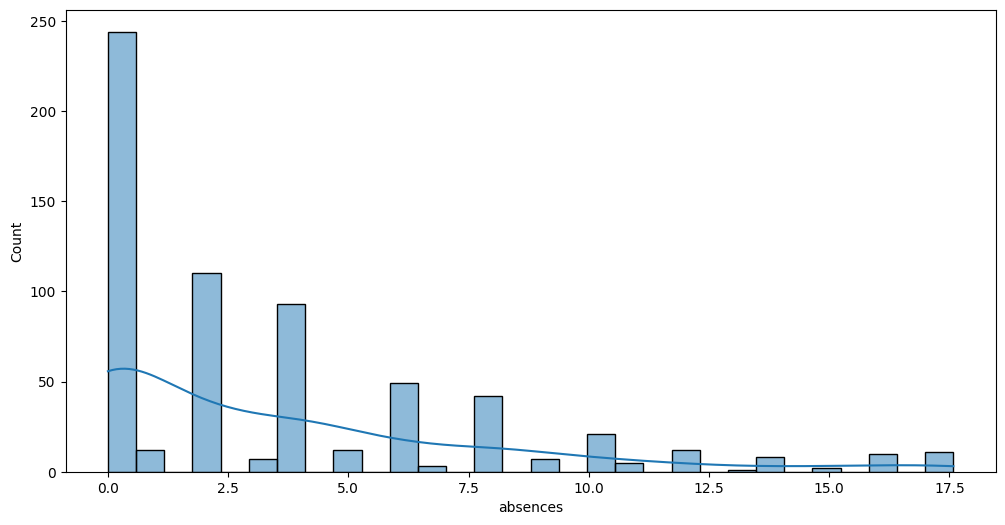

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df["absences"], kde=True, bins=30)
plt.show()

In [12]:
# //IQR skewed data

cap outliers 0      4.0
1      2.0
2      6.0
3      0.0
4      0.0
      ... 
644    4.0
645    4.0
646    6.0
647    6.0
648    4.0
Name: absences, Length: 649, dtype: float64


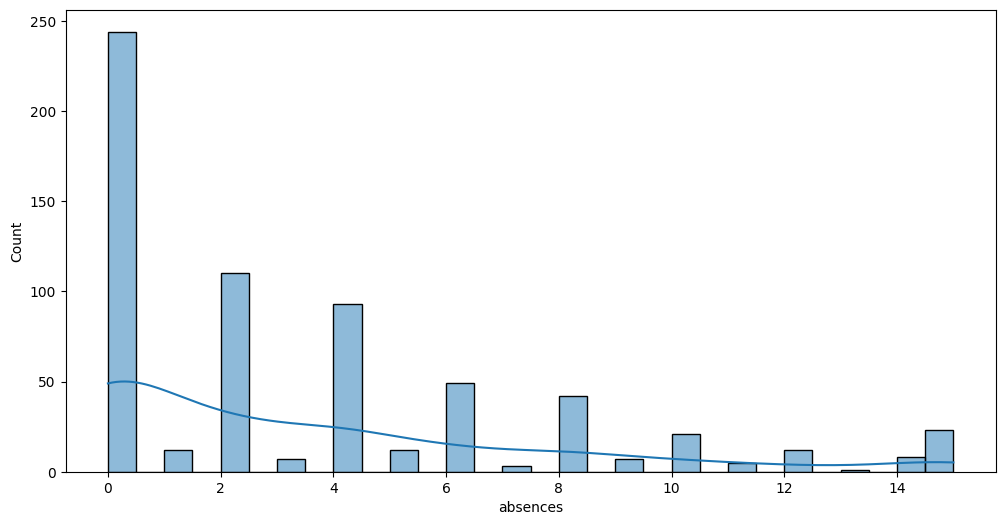

In [13]:
Q1 = df["absences"].quantile(0.25)
Q3 = df["absences"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# capping the outliers
df["absences"] = np.where(
df["absences"] > upper_limit, upper_limit,
np.where(df["absences"] < lower_limit, lower_limit, df["absences"])
)

print("cap outliers",df["absences"])


plt.figure(figsize=(12, 6))
sns.histplot(data=df["absences"], kde=True, bins=30)
plt.show()

In [14]:
import numpy as np
import pandas as pd

# Select only numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Apply IQR capping to each numerical column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] > upper_limit,
        upper_limit,
        np.where(df[col] < lower_limit, lower_limit, df[col])
    )

print("Outliers capped successfully!")

Outliers capped successfully!


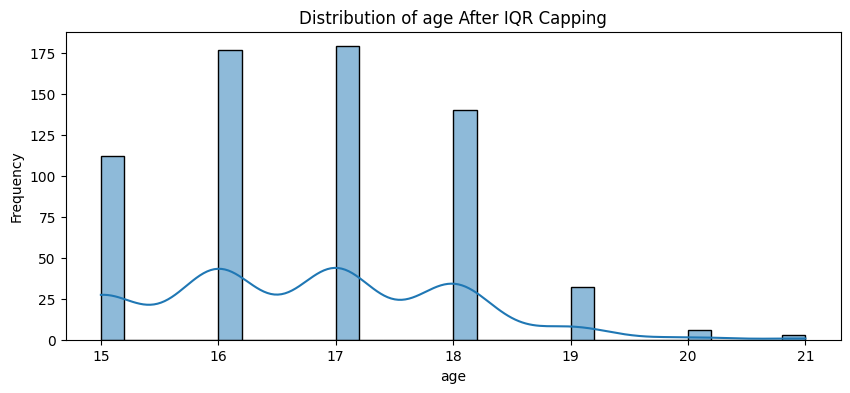

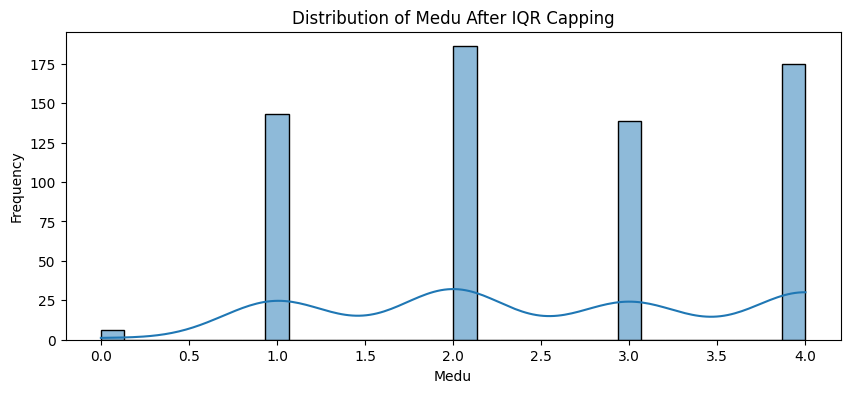

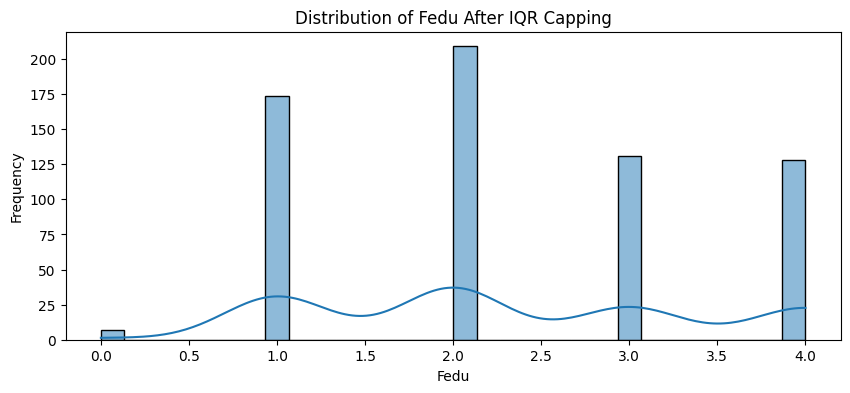

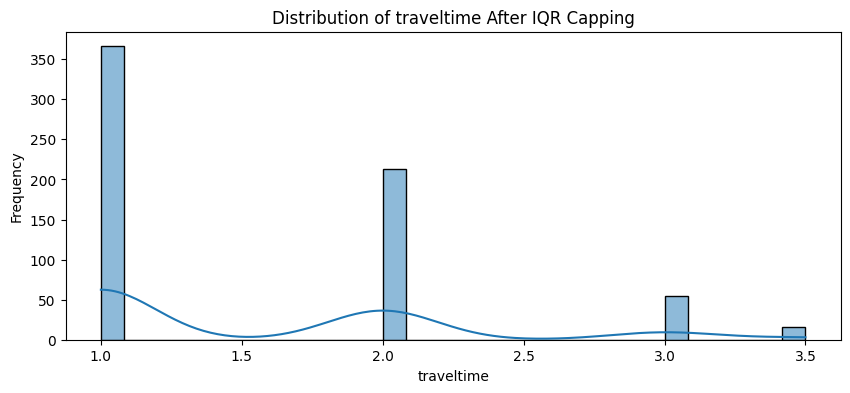

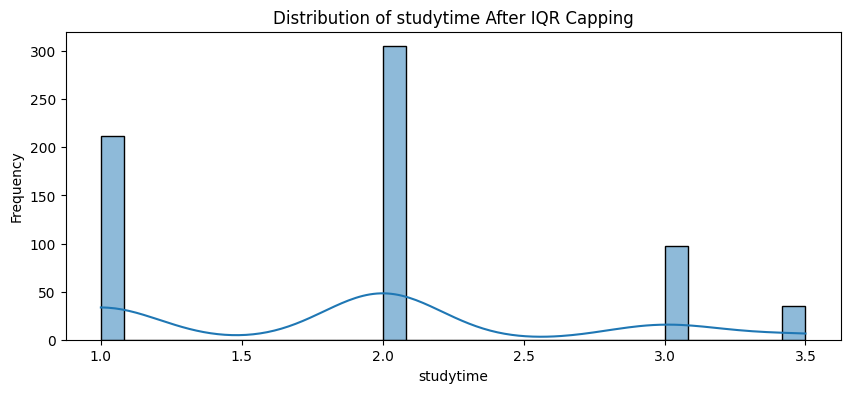

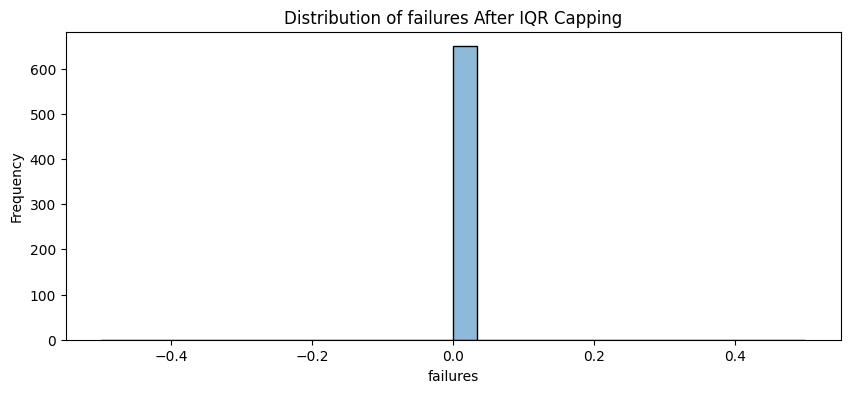

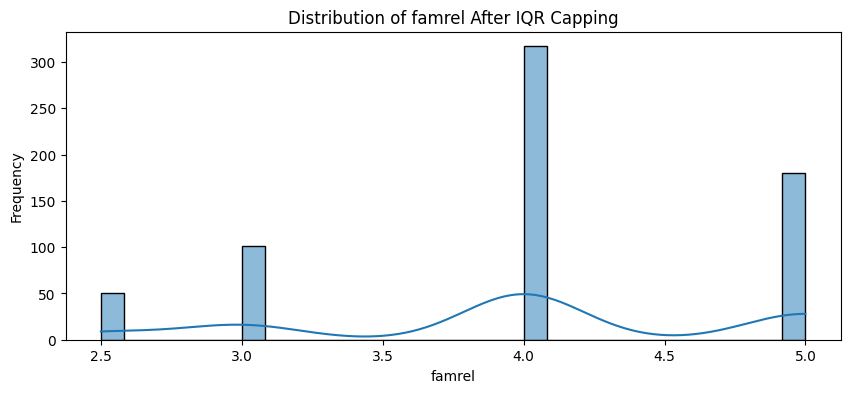

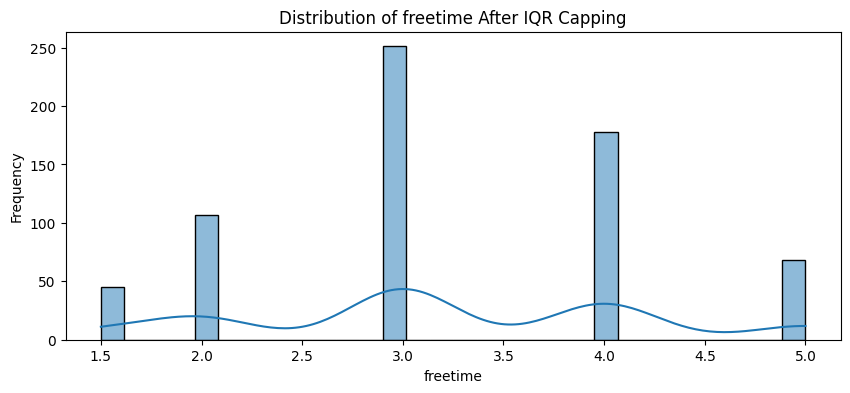

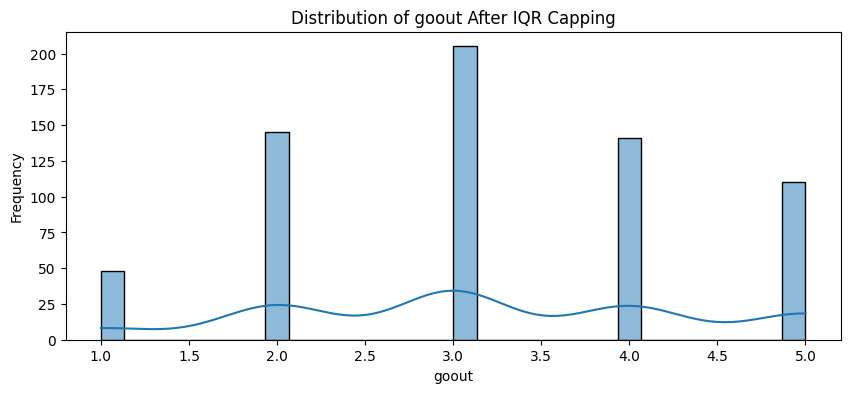

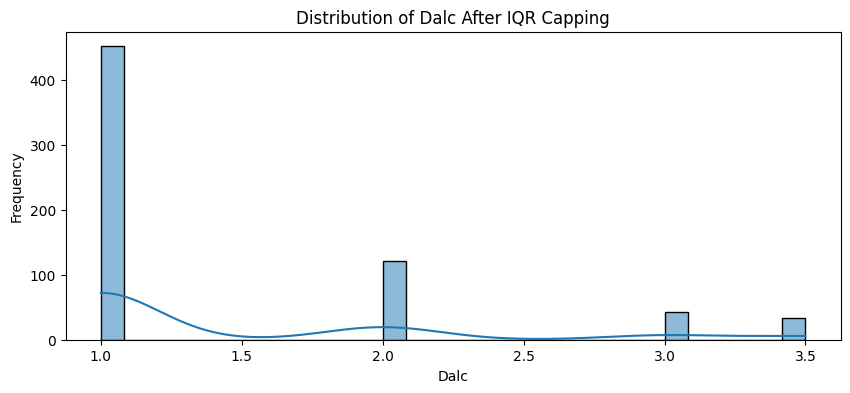

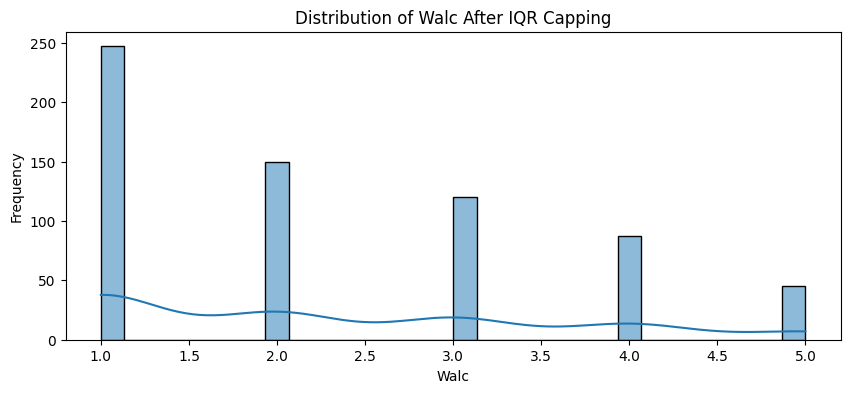

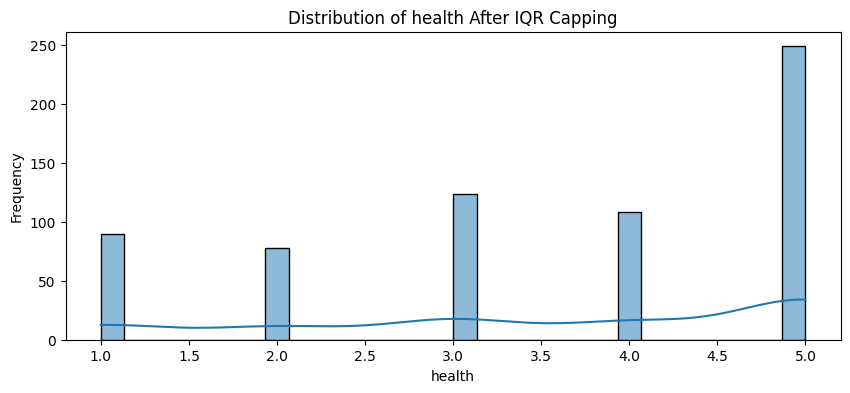

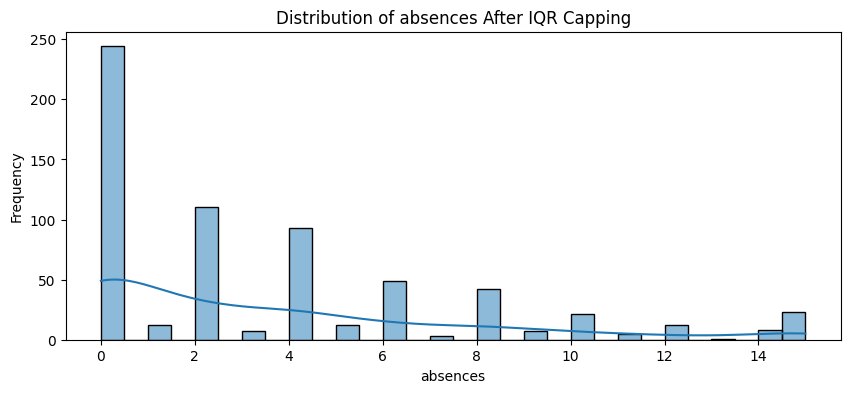

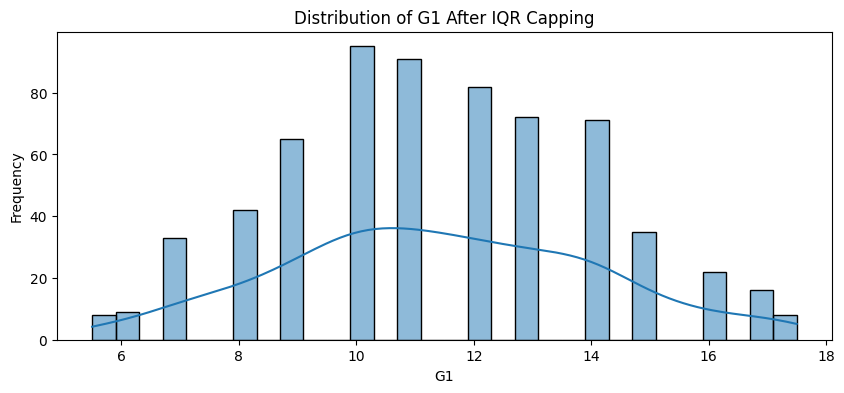

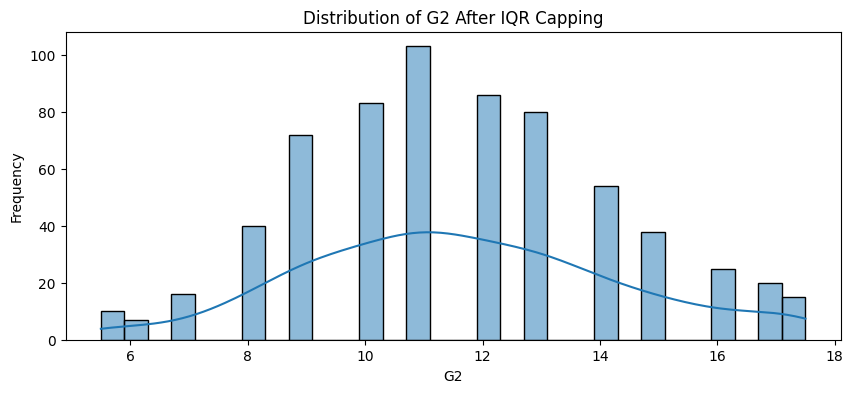

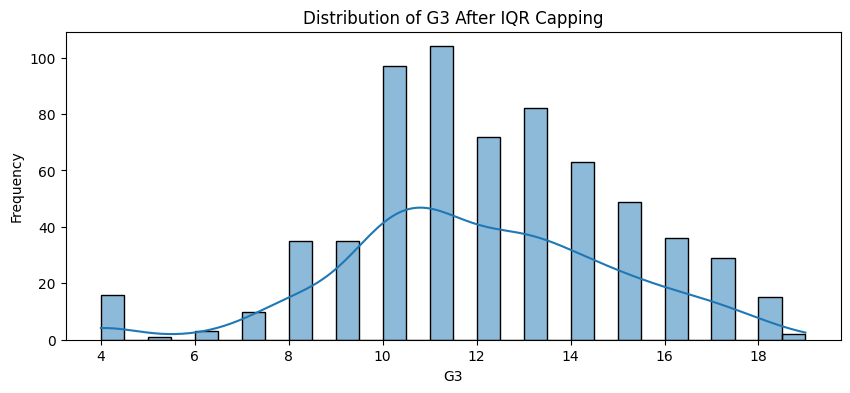

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} After IQR Capping")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [16]:
# percentile method

In [17]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.0,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.742681,2.514638,2.306626,1.556240,1.903698,0.0,4.003852,3.214946,3.184900,1.449923,2.280431,3.536210,3.510015,11.408320,11.618644,12.003082
std,1.212097,1.134552,1.099931,0.711672,0.767523,0.0,0.781480,0.984655,1.175766,0.759835,1.284380,1.446259,4.085918,2.679597,2.691684,2.916533
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.0,2.500000,1.500000,1.000000,1.000000,1.000000,1.000000,0.000000,5.500000,5.500000,4.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.0,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.0,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.0,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,21.000000,4.000000,4.000000,3.500000,3.500000,0.0,5.000000,5.000000,5.000000,3.500000,5.000000,5.000000,15.000000,17.500000,17.500000,19.000000


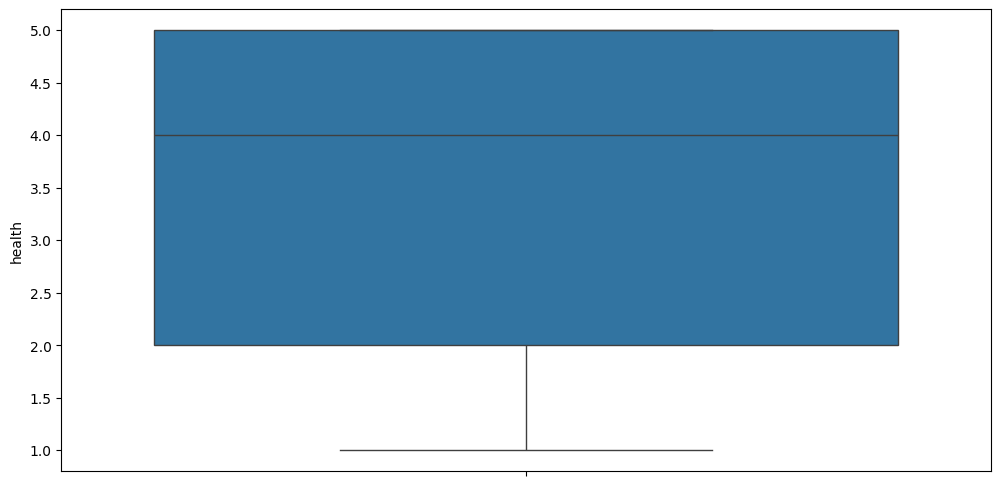

In [18]:
import seaborn as sns

plt.figure(figsize=(12, 6))
# sns.histplot(data=df["health"], kde=True, bins=30)
sns.boxplot(data=df["health"])
plt.show()

In [19]:
upper_limit = df["absences"].quantile(0.99)
lower_limit = df["absences"].quantile(0.01)
upper_limit
lower_limit

np.float64(0.0)

In [20]:
upper_limit = df["health"].quantile(0.99)
lower_limit = df["health"].quantile(0.01)

outliers = df[
    (df["health"] >= upper_limit) | (df["health"] <= lower_limit)
]

print(outliers)

    school sex   age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
3       GP   F  15.0       U     GT3       T   4.0   2.0    health  services   
4       GP   F  16.0       U     GT3       T   3.0   3.0     other     other   
5       GP   M  16.0       U     LE3       T   4.0   3.0  services     other   
7       GP   F  17.0       U     GT3       A   4.0   4.0     other   teacher   
8       GP   M  15.0       U     LE3       A   3.0   2.0  services     other   
..     ...  ..   ...     ...     ...     ...   ...   ...       ...       ...   
643     MS   F  18.0       R     GT3       T   4.0   4.0   teacher   at_home   
644     MS   F  19.0       R     GT3       T   2.0   3.0  services     other   
645     MS   F  18.0       U     LE3       T   3.0   1.0   teacher  services   
646     MS   F  18.0       U     GT3       T   1.0   1.0     other     other   
648     MS   M  18.0       R     LE3       T   3.0   2.0  services     other   

     ... famrel freetime  goout  Dalc  

In [21]:
# clean dataset without outliers
df_clean = df[
    (df["health"] > lower_limit) & (df["health"] < upper_limit)
]

print(df_clean)
# plt.figure(figsize=(12, 6))
# sns.histplot(data=df_clean["health"], kde=True, bins=30)
# plt.show()

    school sex   age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F  18.0       U     GT3       A   4.0   4.0   at_home   teacher   
1       GP   F  17.0       U     GT3       T   1.0   1.0   at_home     other   
2       GP   F  15.0       U     LE3       T   1.0   1.0   at_home     other   
6       GP   M  16.0       U     LE3       T   2.0   2.0     other     other   
10      GP   F  15.0       U     GT3       T   4.0   4.0   teacher    health   
..     ...  ..   ...     ...     ...     ...   ...   ...       ...       ...   
636     MS   M  18.0       U     GT3       T   4.0   4.0   teacher   teacher   
638     MS   M  17.0       U     GT3       T   2.0   3.0     other  services   
640     MS   M  18.0       R     GT3       T   4.0   2.0     other     other   
641     MS   F  18.0       R     GT3       T   2.0   2.0   at_home     other   
647     MS   M  17.0       U     LE3       T   3.0   1.0  services  services   

     ... famrel freetime  goout  Dalc  

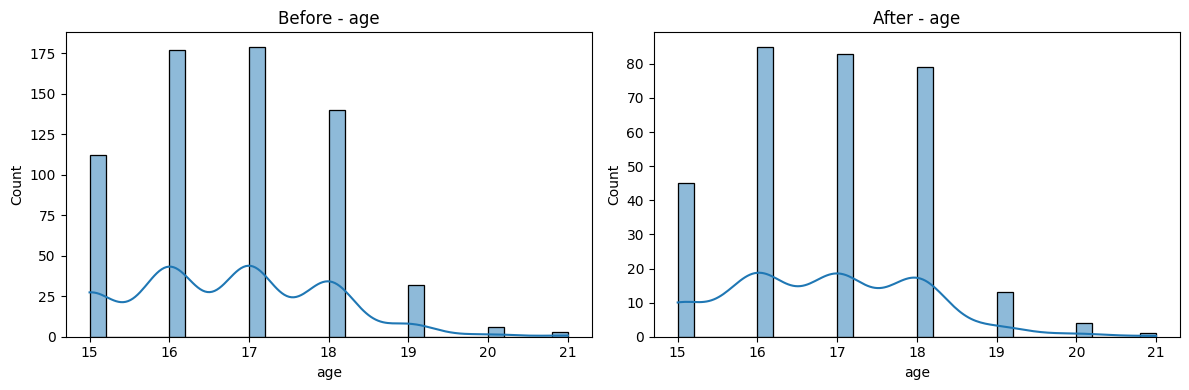

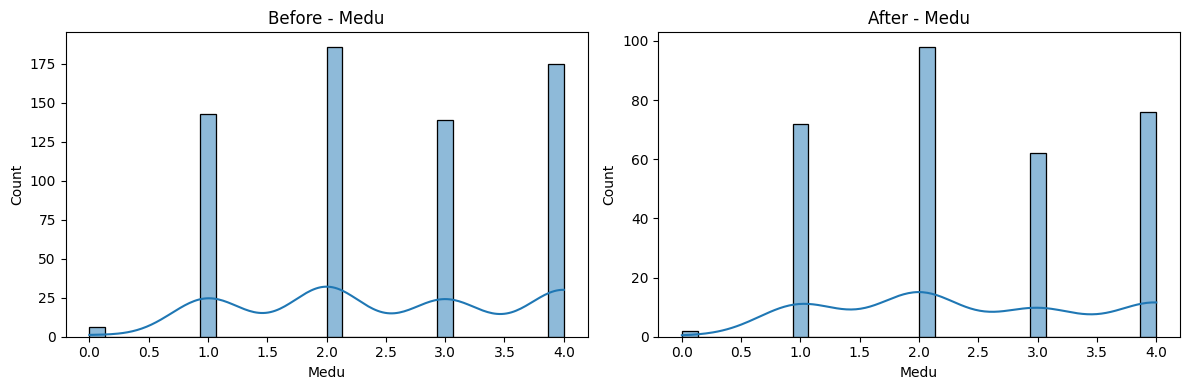

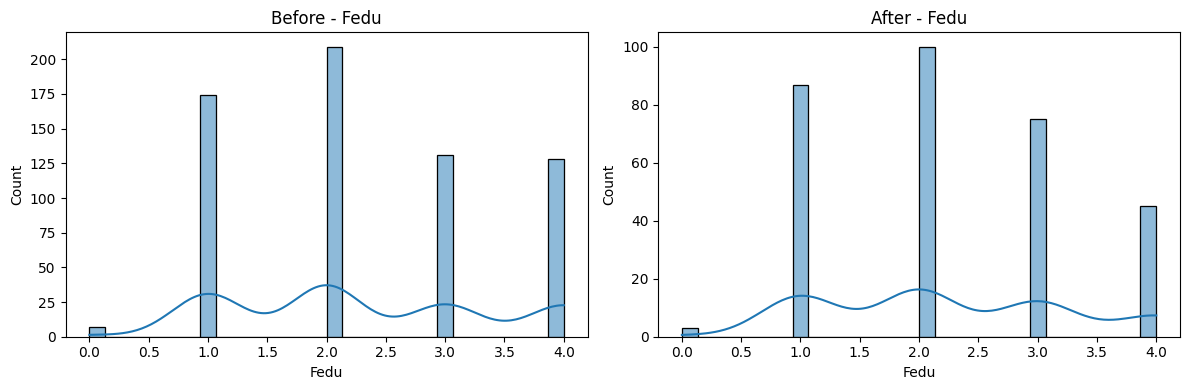

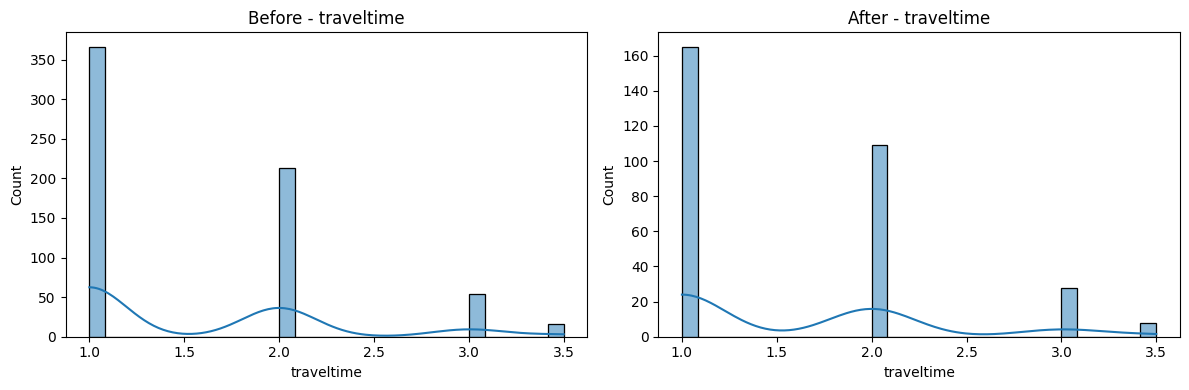

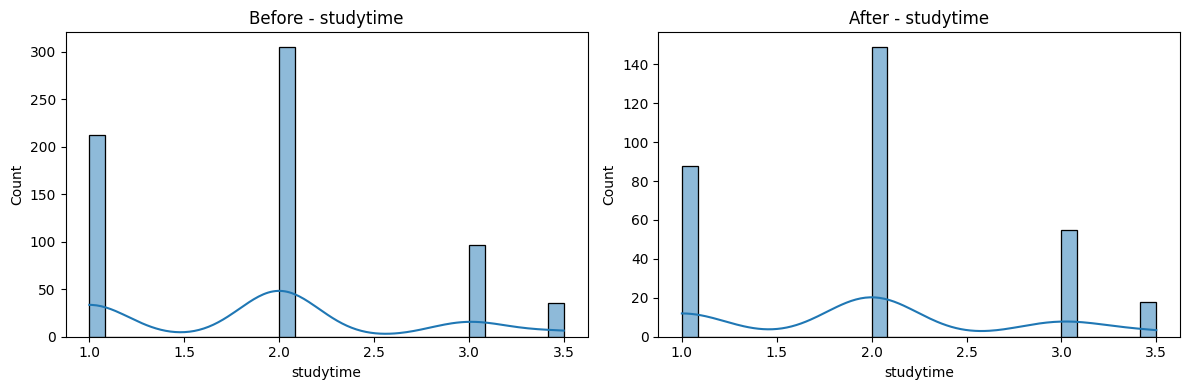

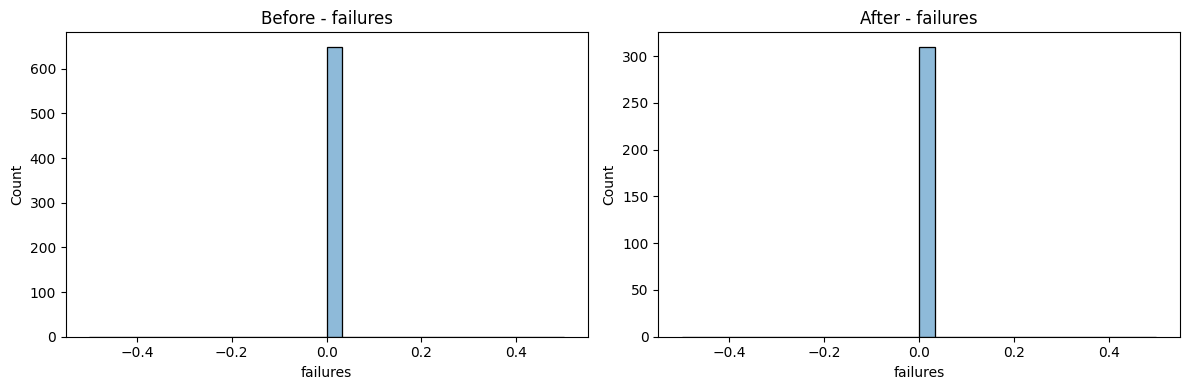

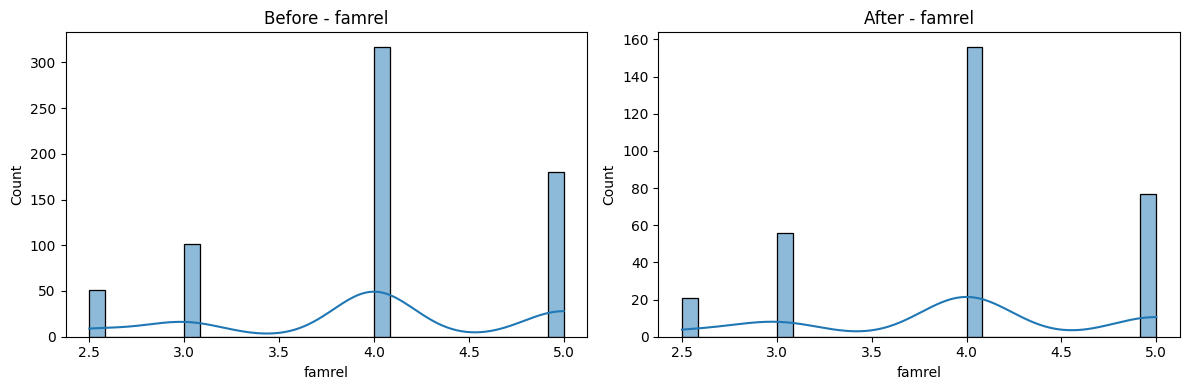

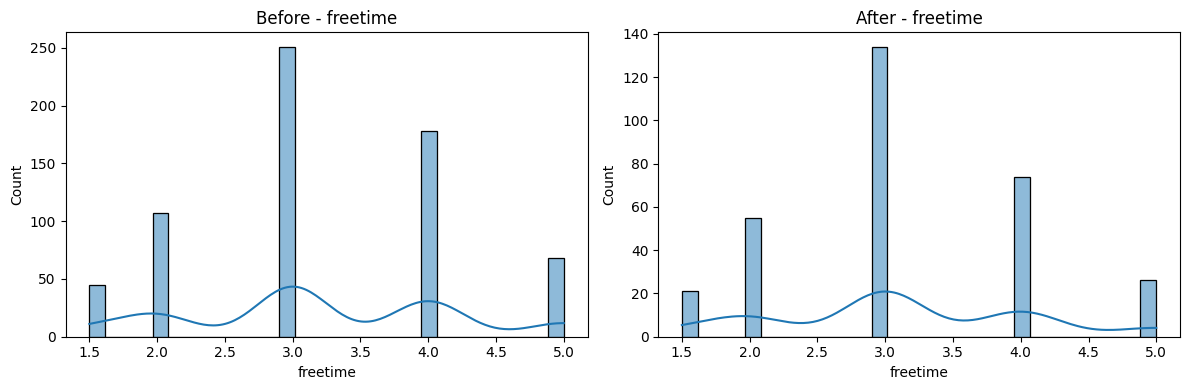

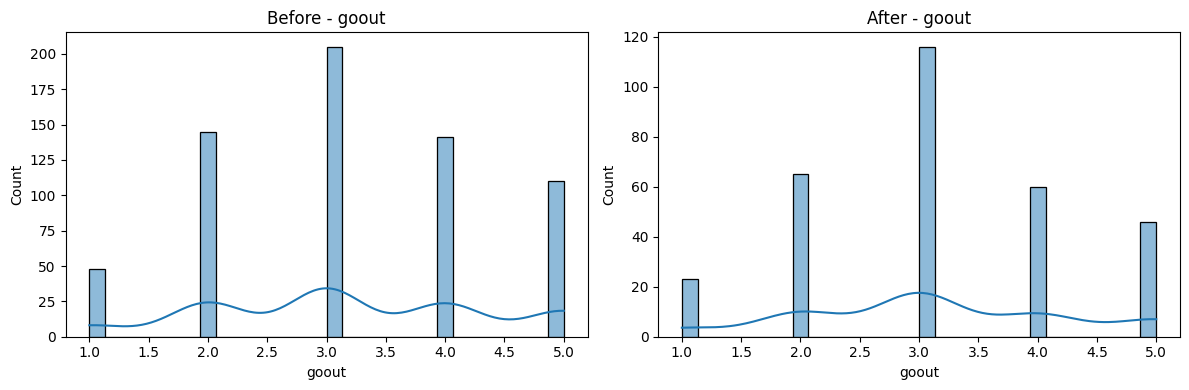

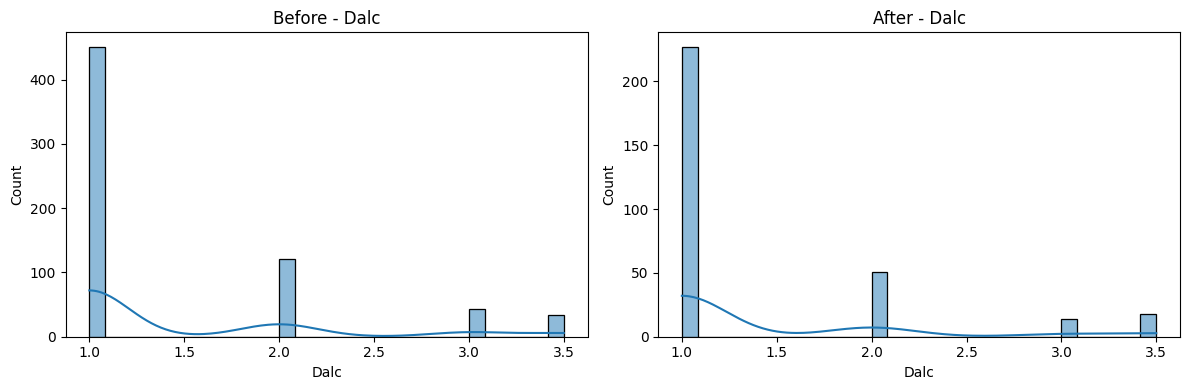

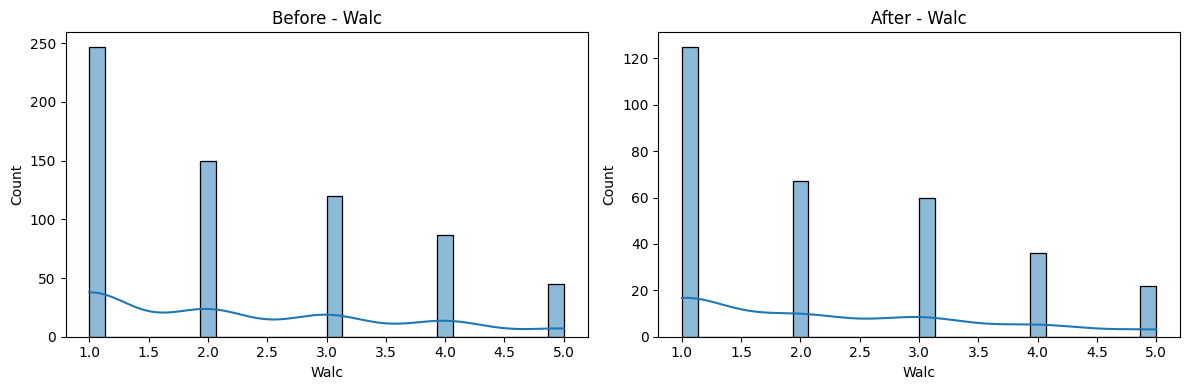

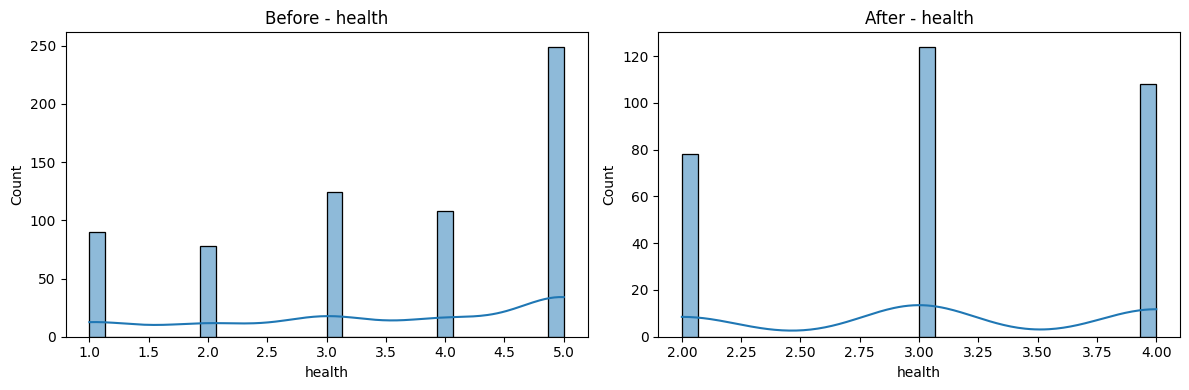

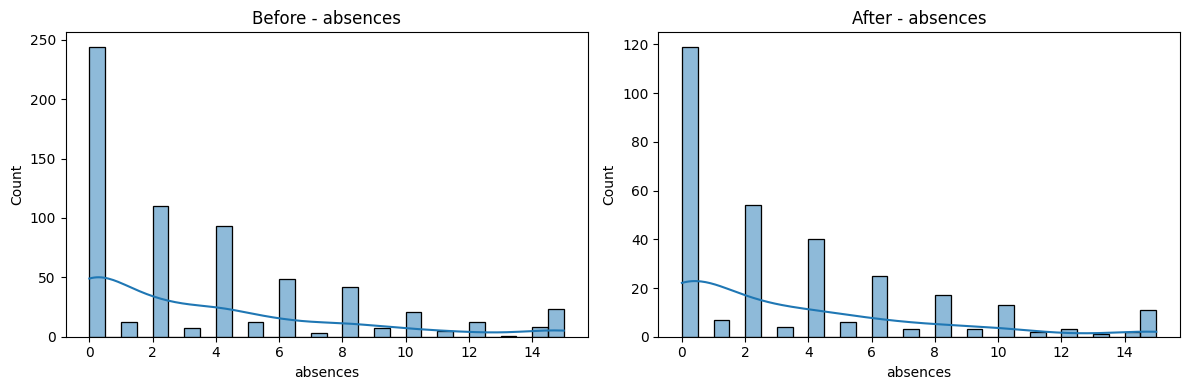

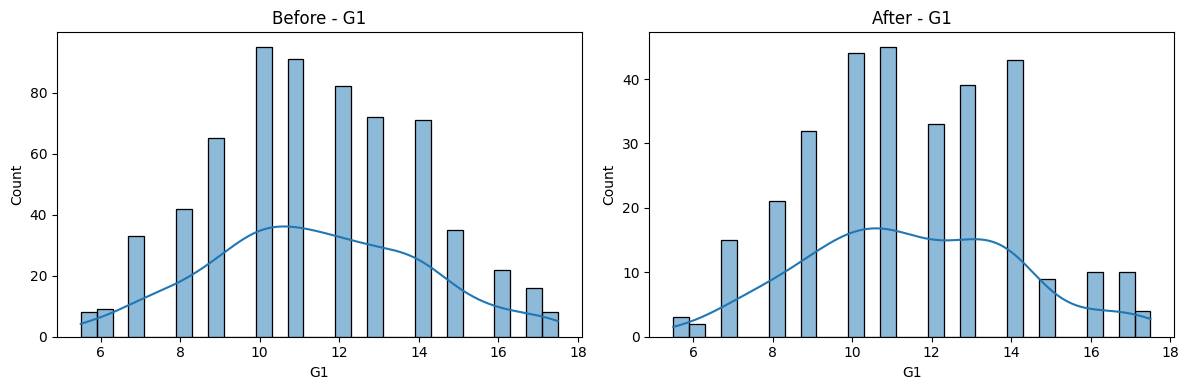

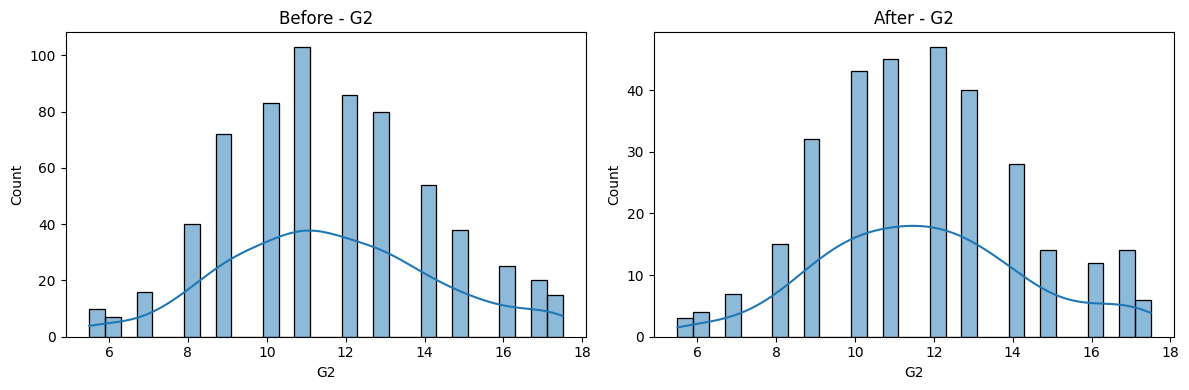

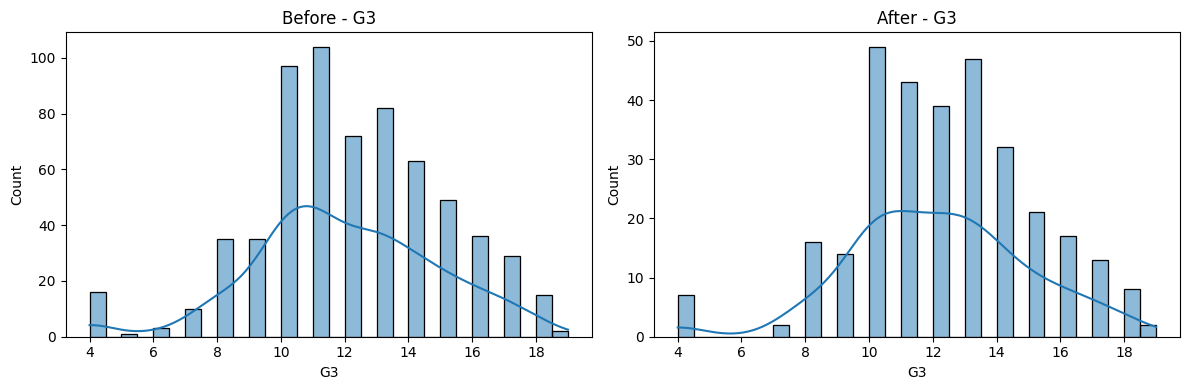

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, bins=30, ax=ax[0])
    ax[0].set_title(f"Before - {col}")

    sns.histplot(df_clean[col], kde=True, bins=30, ax=ax[1])
    ax[1].set_title(f"After - {col}")

    plt.tight_layout()
    plt.show()

In [23]:
import numpy as np

df_capped = df.copy()

numeric_cols = df_capped.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_capped[col] = np.where(
        df_capped[col] > upper_limit,
        upper_limit,
        np.where(df_capped[col] < lower_limit,
                 lower_limit,
                 df_capped[col])
    )

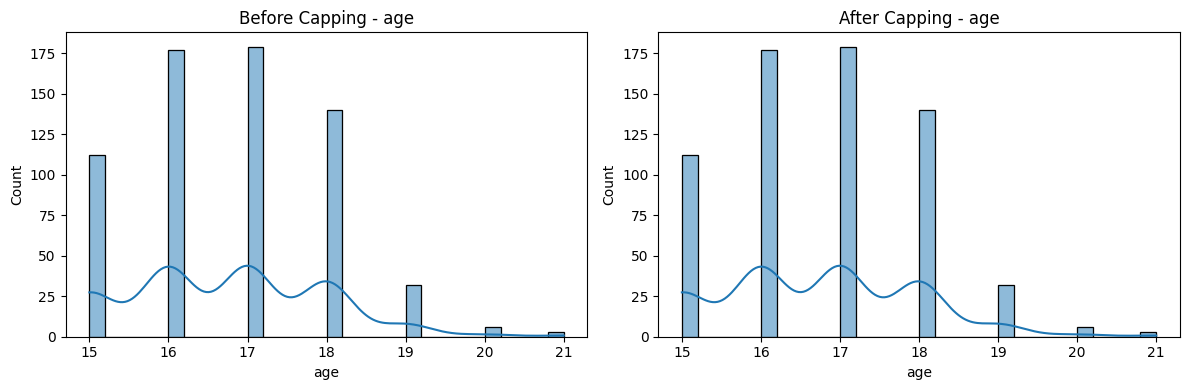

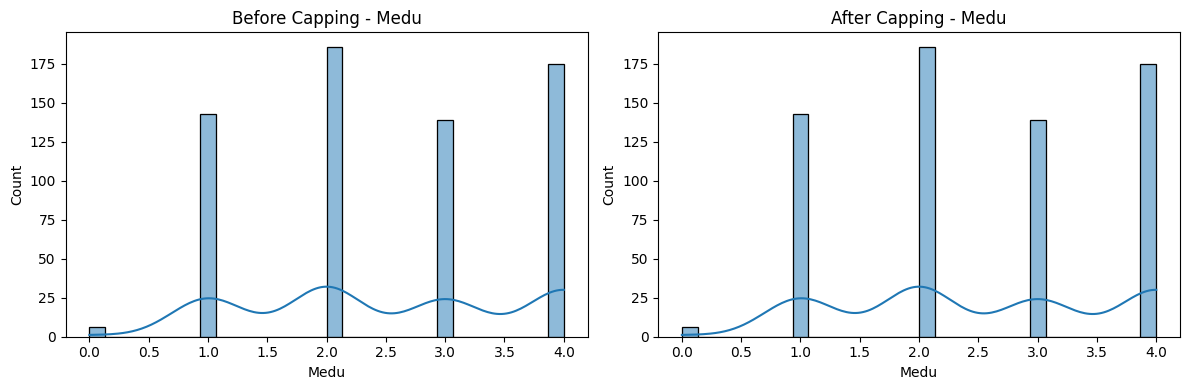

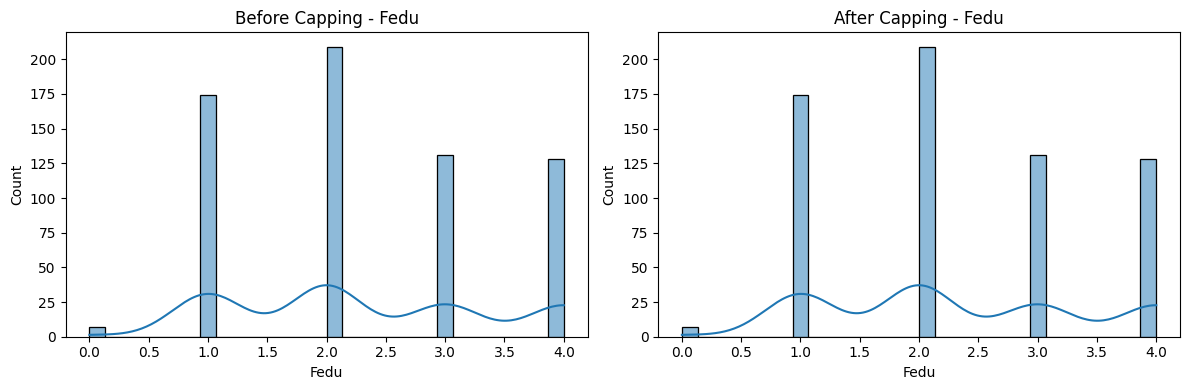

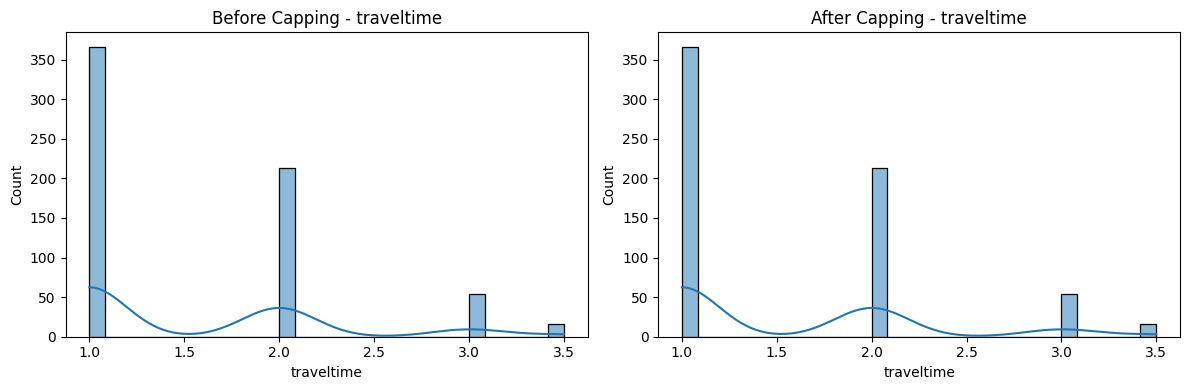

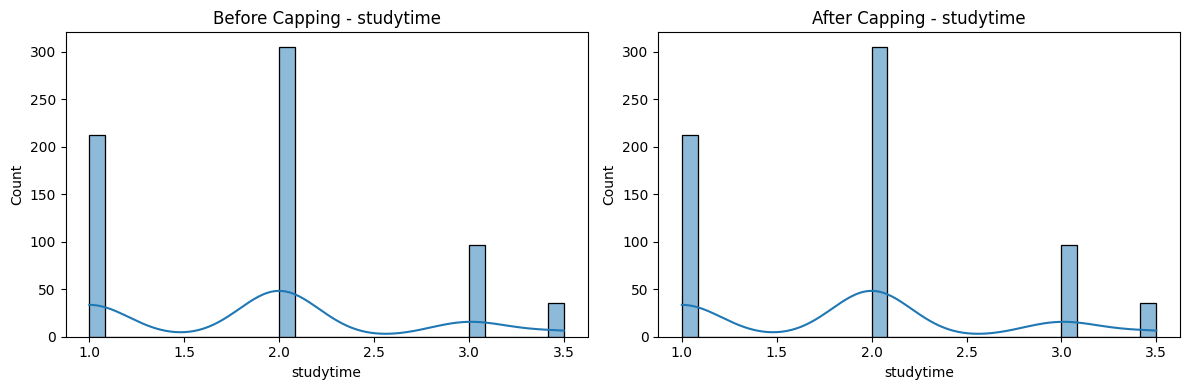

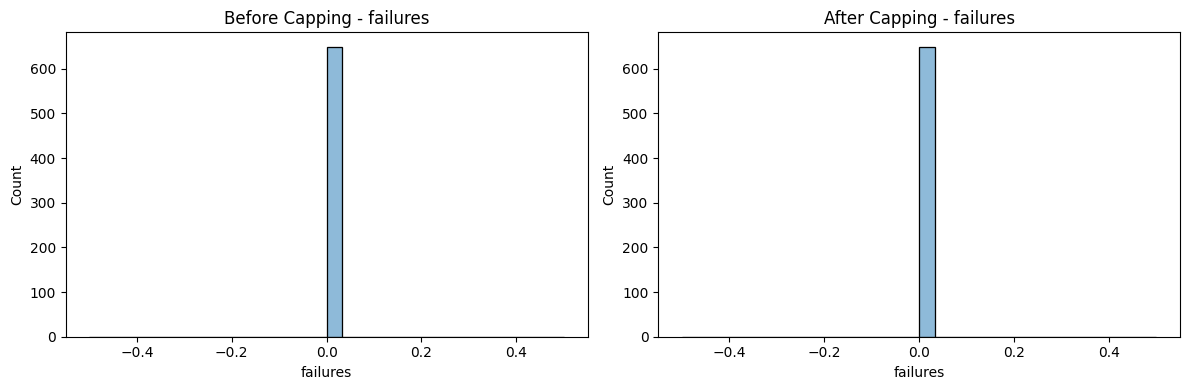

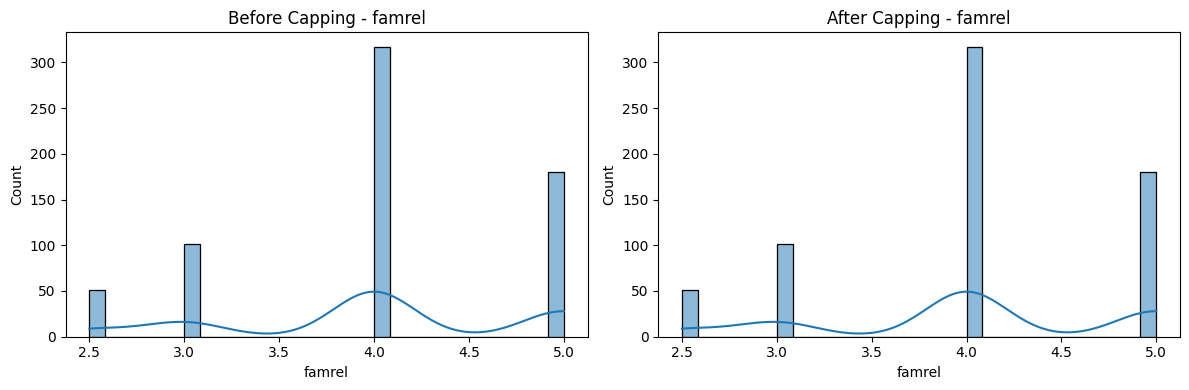

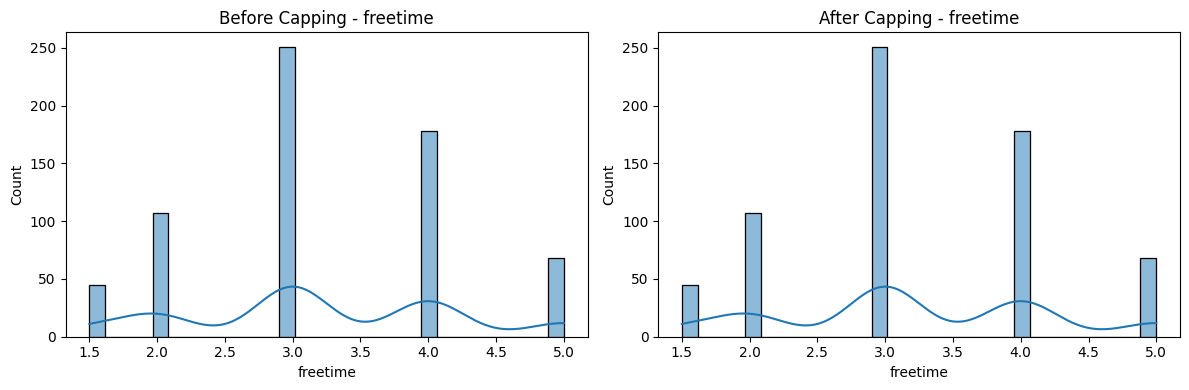

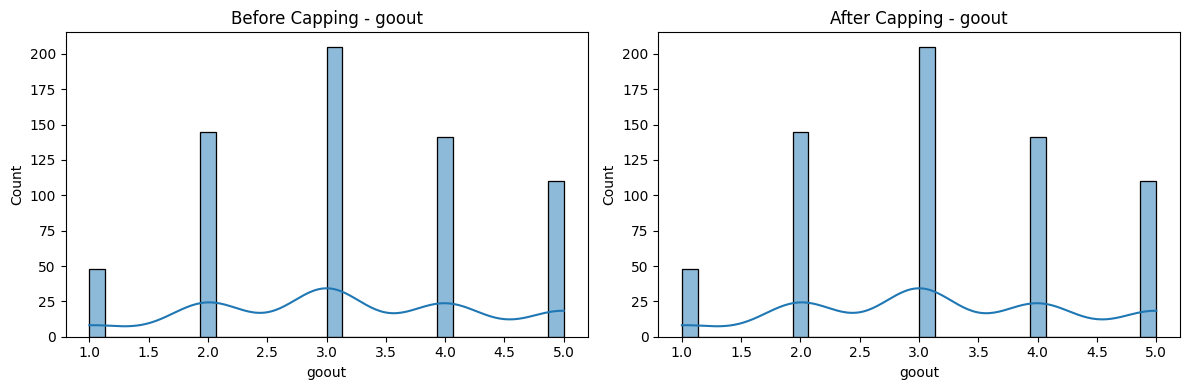

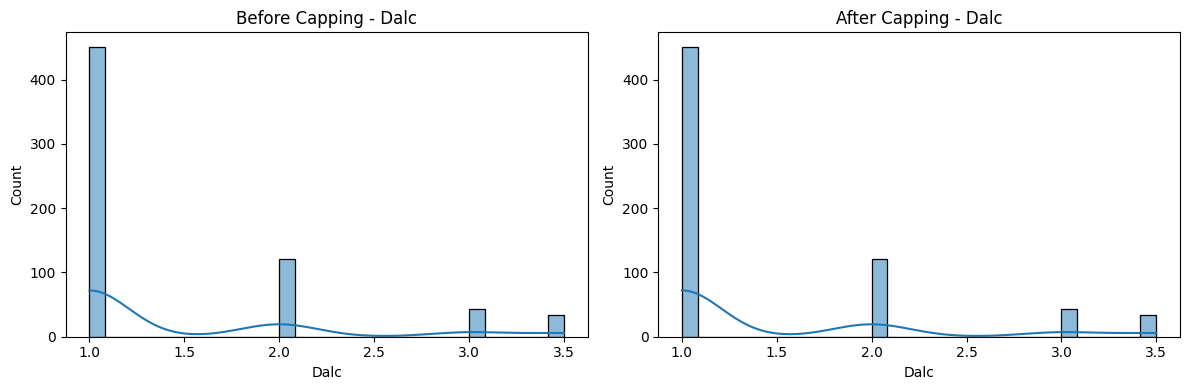

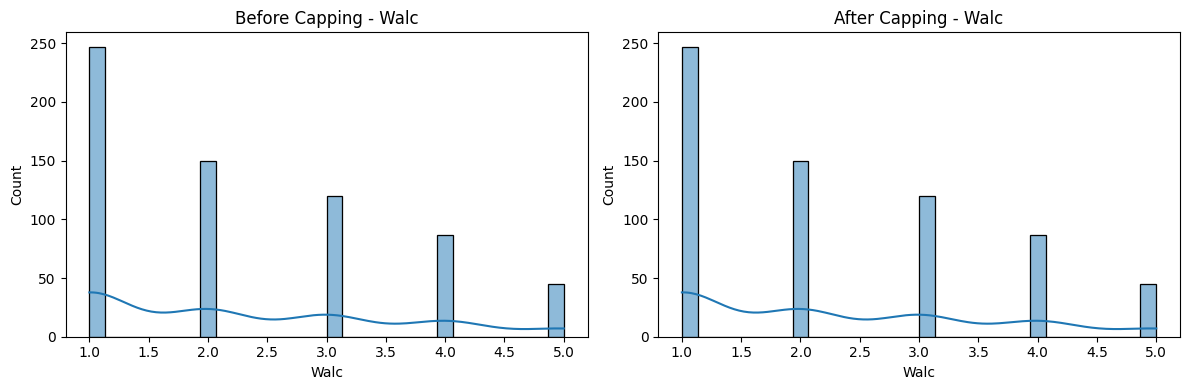

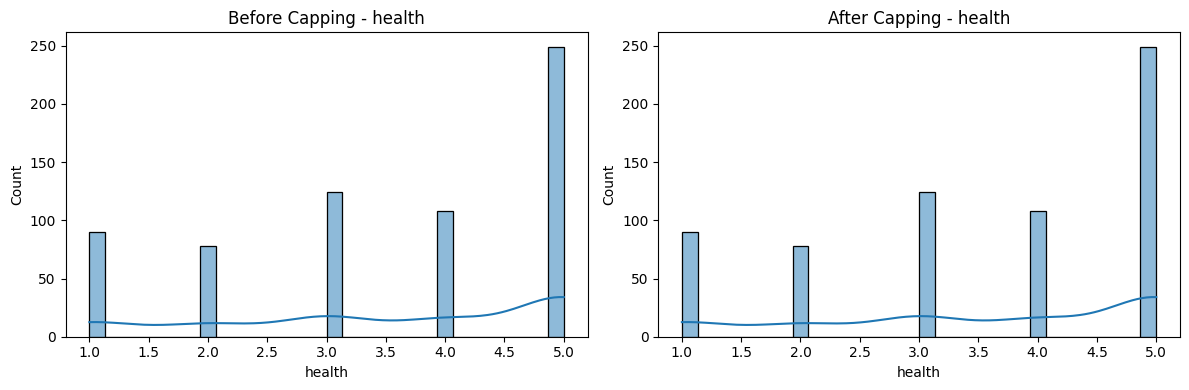

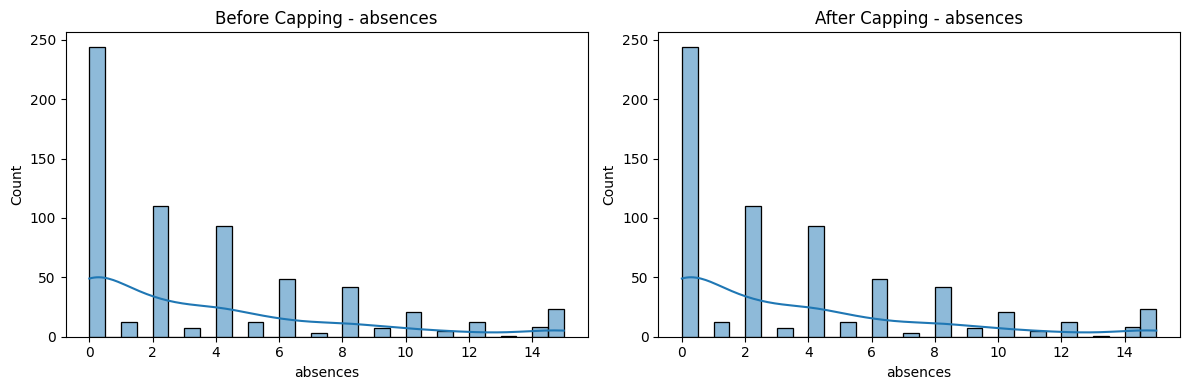

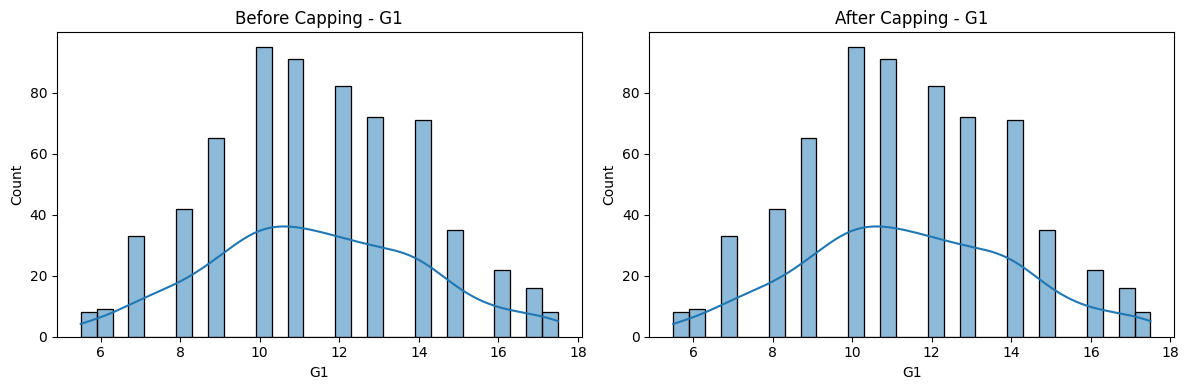

KeyboardInterrupt: 

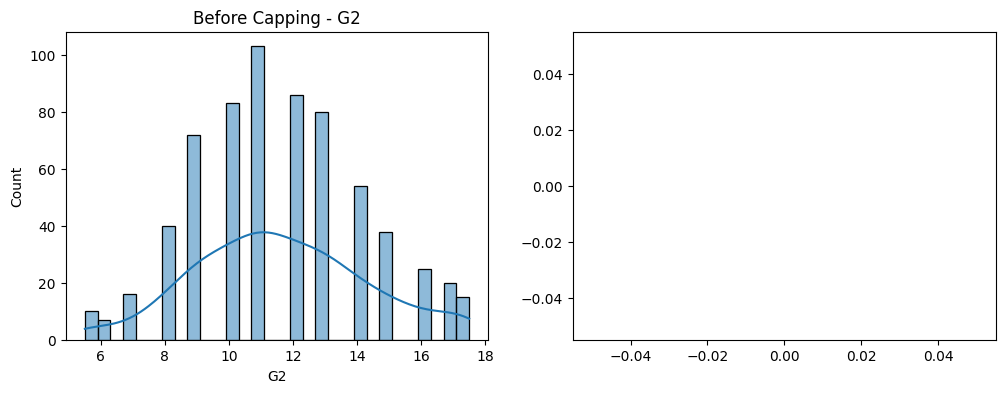

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, bins=30, ax=ax[0])
    ax[0].set_title(f"Before Capping - {col}")

    sns.histplot(df_capped[col], kde=True, bins=30, ax=ax[1])
    ax[1].set_title(f"After Capping - {col}")

    plt.tight_layout()
    plt.show()